In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import xgboost as xgb
import shap
from sklearn.linear_model import QuantileRegressor
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")

train = pd.read_csv("../data/train.csv")
val   = pd.read_csv("../data/val.csv")
test  = pd.read_csv("../data/test.csv")

FEATURE_COLS = joblib.load("../model/feature_cols.pkl")
TARGET_COL   = "total_delivery_min"

X_train, y_train = train[FEATURE_COLS], train[TARGET_COL]
X_val,   y_val   = val[FEATURE_COLS],   val[TARGET_COL]
X_test,  y_test  = test[FEATURE_COLS],  test[TARGET_COL]

print(f"Train: {len(train)} | Val: {len(val)} | Test: {len(test)}")

Train: 6517 | Val: 1769 | Test: 1714


In [2]:
def evaluate(y_true, y_low, y_high, label=""):
    within = ((y_true >= y_low) & (y_true <= y_high)).mean()
    late   = (y_true > y_high).mean()
    early  = (y_true < y_low).mean()
    width  = (y_high - y_low).mean()

    print(f"{label}")
    print(f"  Coverage rate:   {within*100:.1f}%")
    print(f"  Late rate:       {late*100:.1f}%   (llegaron después del promise_end, OBJETIVO 3%)")
    print(f"  Early rate:      {early*100:.1f}%  (llegaron antes del promise_start)")
    print(f"  Avg window:      {width:.1f} min")

    return {"coverage": within, "late": late, "early": early, "width": width}

In [3]:
TAU_LOW  = 0.15
TAU_HIGH = 0.97 # 3% llega tarde

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

lr_low  = QuantileRegressor(quantile=TAU_LOW,  alpha=0.1, solver="highs")
lr_high = QuantileRegressor(quantile=TAU_HIGH, alpha=0.1, solver="highs")

lr_low.fit(X_train_sc,  y_train)
lr_high.fit(X_train_sc, y_train)

val_low_lr  = lr_low.predict(X_val_sc)
val_high_lr = lr_high.predict(X_val_sc)

metrics_lr_val = evaluate(y_val, val_low_lr, val_high_lr, "Lineal - Validación")

Lineal - Validación
  Coverage rate:   81.8%
  Late rate:       3.1%   (llegaron después del promise_end, OBJETIVO 3%)
  Early rate:      15.1%  (llegaron antes del promise_start)
  Avg window:      53.1 min


In [4]:
xgb_params = {
    "objective":      "reg:quantileerror",
    "n_estimators":   500,
    "learning_rate":  0.05,
    "max_depth":      4,
    "subsample":      0.8,
    "colsample_bytree": 0.8,
    "random_state":   42,
}

xgb_low  = xgb.XGBRegressor(**xgb_params, quantile_alpha=TAU_LOW)
xgb_high = xgb.XGBRegressor(**xgb_params, quantile_alpha=TAU_HIGH)

xgb_low.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100
)
xgb_high.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100
)

val_low_xgb  = xgb_low.predict(X_val)
val_high_xgb = xgb_high.predict(X_val)

metrics_xgb_val = evaluate(y_val, val_low_xgb, val_high_xgb, "XGBoost - Validación")


[0]	validation_0-quantile:3.07902
[100]	validation_0-quantile:1.92862
[200]	validation_0-quantile:1.91063
[300]	validation_0-quantile:1.91069
[400]	validation_0-quantile:1.91023
[499]	validation_0-quantile:1.91517
[0]	validation_0-quantile:1.65632
[100]	validation_0-quantile:1.12533
[200]	validation_0-quantile:1.13164
[300]	validation_0-quantile:1.14422
[400]	validation_0-quantile:1.15520
[499]	validation_0-quantile:1.16482
XGBoost - Validación
  Coverage rate:   77.8%
  Late rate:       4.7%   (llegaron después del promise_end, OBJETIVO 3%)
  Early rate:      17.5%  (llegaron antes del promise_start)
  Avg window:      30.9 min


xgb_high tiene pérdida en la validación pasando los 100 árboles, voy a volver a armarlo con early stop

In [8]:
xgb_params = {
    "objective":      "reg:quantileerror",
    "n_estimators":   500,
    "learning_rate":  0.05,
    "max_depth":      4,
    "subsample":      0.8,
    "colsample_bytree": 0.8,
    "random_state":   42,
}

xgb_low  = xgb.XGBRegressor(**xgb_params, quantile_alpha=TAU_LOW)
xgb_high = xgb.XGBRegressor(**xgb_params, early_stopping_rounds=20, quantile_alpha=TAU_HIGH)

xgb_low.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100
)
xgb_high.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100
)

val_low_xgb  = xgb_low.predict(X_val)
val_high_xgb = xgb_high.predict(X_val)

metrics_xgb_val = evaluate(y_val, val_low_xgb, val_high_xgb, "XGBoost - Validación")


[0]	validation_0-quantile:3.07902


[100]	validation_0-quantile:1.92862
[200]	validation_0-quantile:1.91063
[300]	validation_0-quantile:1.91069
[400]	validation_0-quantile:1.91023
[499]	validation_0-quantile:1.91517
[0]	validation_0-quantile:1.65632
[100]	validation_0-quantile:1.12533
[136]	validation_0-quantile:1.12633
XGBoost - Validación
  Coverage rate:   78.8%
  Late rate:       3.7%   (llegaron después del promise_end, OBJETIVO 3%)
  Early rate:      17.5%  (llegaron antes del promise_start)
  Avg window:      33.2 min


         coverage   late  early   width
Lineal      0.818  0.031  0.151  53.085
XGBoost     0.788  0.037  0.175  33.187


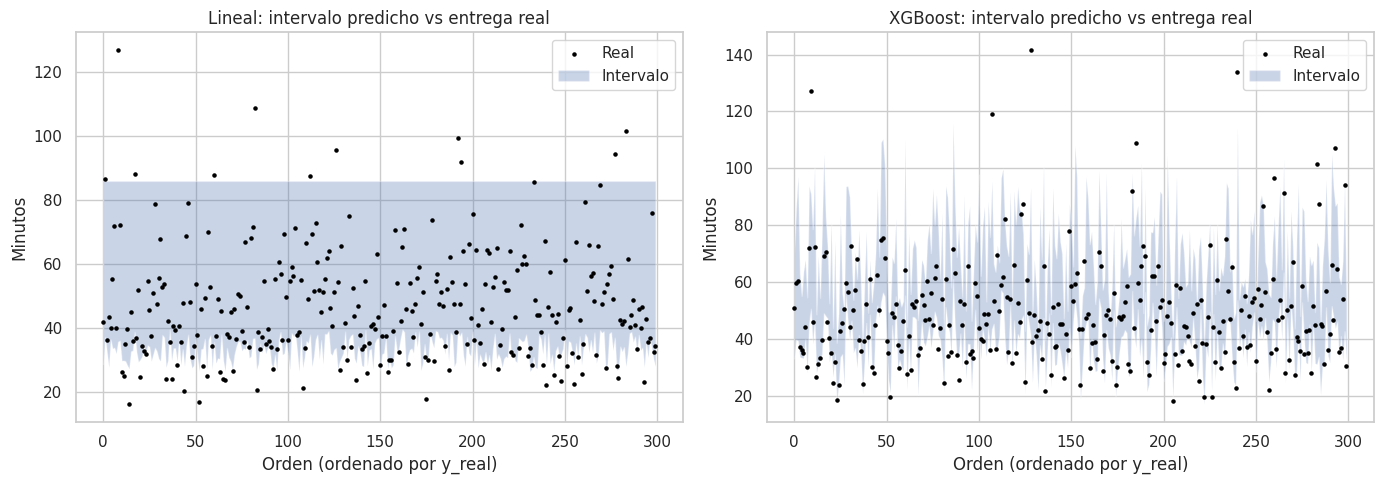

In [15]:
comparison = pd.DataFrame({
    "Lineal":   metrics_lr_val,
    "XGBoost":  metrics_xgb_val,
}).T.round(3)

print(comparison)

# Visualización de los intervalos predichos vs real
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (low, high, label) in zip(axes, [
    (val_low_lr,  val_high_lr,  "Lineal"),
    (val_low_xgb, val_high_xgb, "XGBoost"),
]):
    idx = np.random.choice(len(y_val), 300, replace=False)
    idx = np.sort(idx)
    ax.scatter(range(300), y_val.values[idx], s=5, color="black", label="Real", zorder=3)
    ax.fill_between(range(300), low[idx], high[idx], alpha=0.3, label="Intervalo")
    ax.set_title(f"{label}: intervalo predicho vs entrega real")
    ax.set_xlabel("Orden (ordenado por y_real)")
    ax.set_ylabel("Minutos")
    ax.legend()

plt.tight_layout()
plt.show()